# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 348kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.77MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.45MB/s]


In [2]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


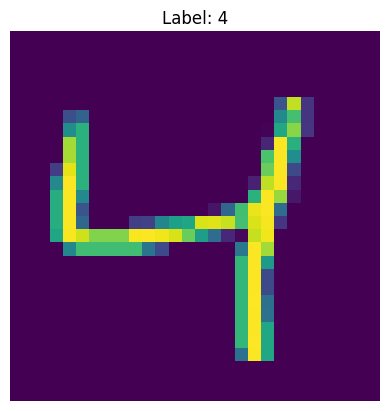

In [3]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [5]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim,hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim,output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [6]:
# ANN 객체 생성
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()# 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [7]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs =model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.003164594992995262  Accuracy: 97.85950469970703 %
Iteration: 1000  Loss: 0.22291260957717896  Accuracy: 97.41194915771484 %
Iteration: 1500  Loss: 0.11751308292150497  Accuracy: 98.07355499267578 %
Iteration: 2000  Loss: 0.3570280373096466  Accuracy: 96.55574798583984 %
Iteration: 2500  Loss: 0.33421289920806885  Accuracy: 97.76220703125 %
Iteration: 3000  Loss: 0.00019938652985729277  Accuracy: 98.46273803710938 %
Iteration: 3500  Loss: 0.2917345464229584  Accuracy: 95.93305969238281 %
Iteration: 4000  Loss: 0.11440752446651459  Accuracy: 95.48550415039062 %
Iteration: 4500  Loss: 0.06837421655654907  Accuracy: 96.69196319580078 %


#### **ANN 학습 결과**

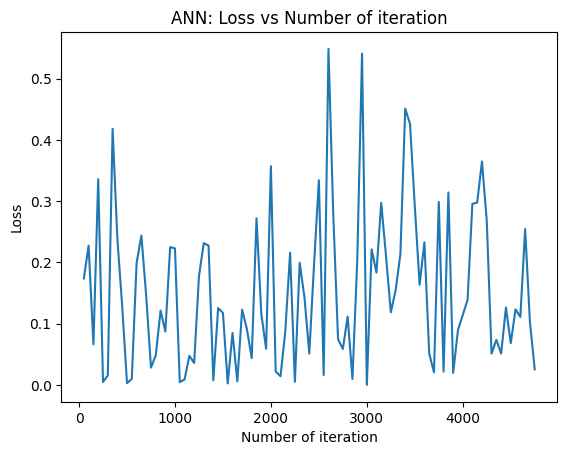

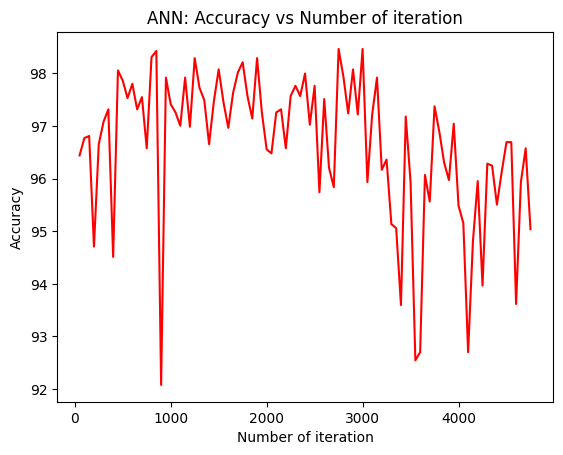

In [8]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
- optimizer를 Adam으로 사용하였고, Loss의 진동이 심하며, iteration이 진행되면서 Loss가 줄어드는 것이 정상이지만 불안정한 모습을 보임
- learning_rate가 0.02로 높은 편으로, learning_rate를 줄일 필요가 있음
- 특히, Adam을 옵티마이저로 설정했고, Adam은 적응형 학습률 옵티마이저로 learning rate가 너무 끄면, 과하게 뛰어넘어서 발산하거나 진동할 수 있기 때문에 적게 설정하는 것이 중요함

- Accuracy는 대부분 높은 수준을 유지하고 있으나, Loss와 마찬가지로 iteration이 진행될 수록 불안정해짐 -> 이는 해당 학습 데이터에 너무 overfitting한 결과 일 수 있기 때문에 regularization 튜닝 기법을 사용할 수 있음 -> 그러나, 이번 학습의 결과 같은 경우에는 learning_rate가 큰 것이 원인이 될 수 있기 때문에 이를 조정해 보는 것이 먼저 수행되고 Accuracy를 다시 살펴볼 필요가 잇음


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [15]:
import torch

class ANNTrainer:
    def __init__(self, model, train_loader, test_loader, loss_fn, optimizer, device):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = device

        # 모니터링 변수
        self.count = 0
        self.loss_list = []
        self.iteration_list = []
        self.accuracy_list = []

    def train(self, epochs=10, log_interval=50, print_interval=500):
        for epoch in range(epochs):
            for i, (images, labels) in enumerate(self.train_loader):
                # Flatten input
                images = images.view(-1, 28*28).to(self.device)
                labels = labels.to(self.device)

                # Forward + Backward + Optimize
                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.loss_fn(outputs, labels)
                loss.backward()
                self.optimizer.step()

                self.count += 1

                # 로깅 및 정확도 계산
                if self.count % log_interval == 0:
                    accuracy = self.evaluate()
                    self.loss_list.append(loss.item())
                    self.iteration_list.append(self.count)
                    self.accuracy_list.append(accuracy)

                if self.count % print_interval == 0:
                    print(f"Iteration: {self.count}  Loss: {loss.item():.4f}  Accuracy: {accuracy:.2f}%")

    def evaluate(self):
        self.model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in self.test_loader:
                images = images.view(-1, 28*28).to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(images)
                predicted = torch.max(outputs.data, 1)[1]
                total += len(labels)
                correct += (predicted == labels).sum().item()
        self.model.train()
        return 100 * correct / total

    def get_logs(self):
        return self.iteration_list, self.loss_list, self.accuracy_list


In [19]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습

hidden_dims = [50, 100, 150, 200]
logs = {}

for h_dim in hidden_dims:
    model = ANNModel(input_dim=784, hidden_dim=h_dim, output_dim=10)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
    trainer = ANNTrainer(model, train_loader, test_loader, loss_ftn, optimizer, device)
    trainer.train(epochs=5)

    iteration_list, loss_list, accuracy_list = trainer.get_logs()

    logs[h_dim] = (iteration_list, loss_list, accuracy_list)


Iteration: 500  Loss: 0.1793  Accuracy: 98.31%
Iteration: 1000  Loss: 0.3877  Accuracy: 98.11%
Iteration: 1500  Loss: 0.1260  Accuracy: 96.48%
Iteration: 2000  Loss: 0.1078  Accuracy: 97.30%
Iteration: 500  Loss: 0.0491  Accuracy: 97.55%
Iteration: 1000  Loss: 0.1143  Accuracy: 96.50%
Iteration: 1500  Loss: 0.0866  Accuracy: 97.72%
Iteration: 2000  Loss: 0.0403  Accuracy: 96.83%
Iteration: 500  Loss: 0.0681  Accuracy: 96.09%
Iteration: 1000  Loss: 0.1779  Accuracy: 96.56%
Iteration: 1500  Loss: 0.0630  Accuracy: 97.30%
Iteration: 2000  Loss: 0.3190  Accuracy: 93.91%
Iteration: 500  Loss: 0.0557  Accuracy: 97.20%
Iteration: 1000  Loss: 0.0878  Accuracy: 96.96%
Iteration: 1500  Loss: 0.3712  Accuracy: 92.72%
Iteration: 2000  Loss: 0.2095  Accuracy: 93.29%


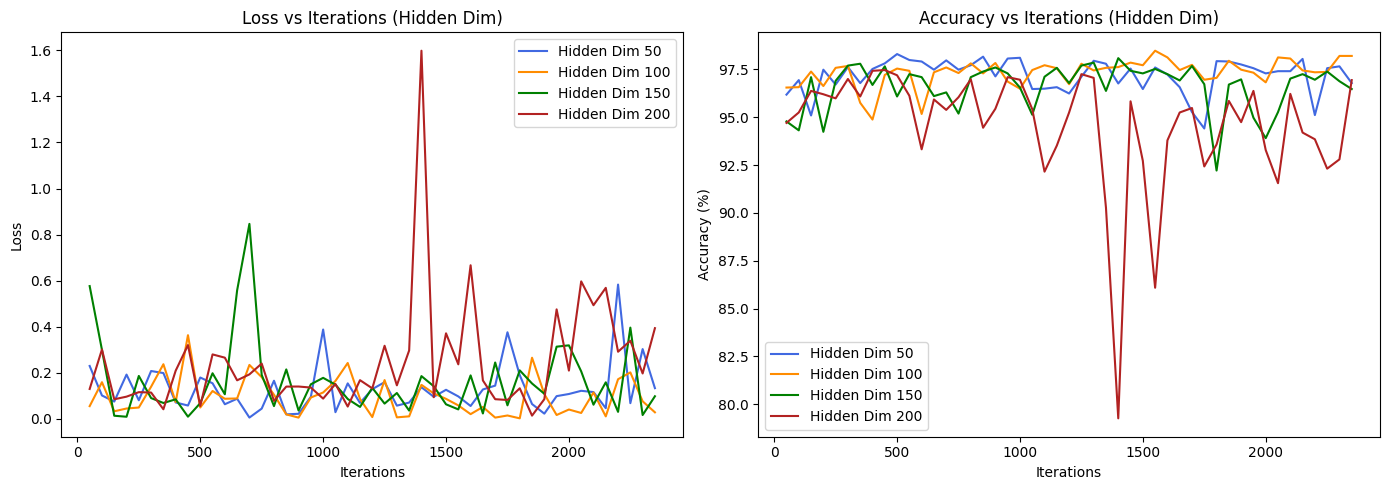

In [20]:
# 실험 1 모델 학습 결과 시각화
import matplotlib.pyplot as plt

# 그래프 색상 자동 지정용
colors = ['royalblue', 'darkorange', 'green', 'firebrick']

plt.figure(figsize=(14, 5))

# --------- (1) Loss vs Iterations ---------
plt.subplot(1, 2, 1)
for (h_dim, (iters, losses, _)), color in zip(logs.items(), colors):
    plt.plot(iters, losses, label=f'Hidden Dim {h_dim}', color=color)
plt.title('Loss vs Iterations (Hidden Dim)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()

# --------- (2) Accuracy vs Iterations ---------
plt.subplot(1, 2, 2)
for (h_dim, (iters, _, accs)), color in zip(logs.items(), colors):
    plt.plot(iters, accs, label=f'Hidden Dim {h_dim}', color=color)
plt.title('Accuracy vs Iterations (Hidden Dim)')
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- 200을 제외한 hidden_dim에서는 대부분 loss는 낮아지면서 수렴하는 모습을 보이지만, 200은 중간에 갑자기 loss의 엄청난 상승이 보이며 불안정함 또한, 100은 안정적인 loss 감소곡선을 보임

- 100이 평균적으로 가장 높은 accuracy를 유지하고 잇음 그러나, 50과 150은 약간 오르락 내리락 하는 모습을 볼 수 있고, 200은 accurary가 심하게 오르락 내리락하는 모습을 보여줌 -> 이는 overfitting이 되었으며 학습이 불안정함을 의미함

- 이를 통해서, 무조건 많은 은닉층의 개수가 좋은 것은 아님을 알게 되었음 -> 즉 적절한 hidden_dim을 찾는 것이 중요함
  - 너무 작으면, 학습이 덜 되는 문제가 발생
  - 너무 크면, 과적합되고 불안정해서 오히려 성능이 하락하는 문제가 발생

- 현재 실험 모델에서는 hidden_dim 100이 가장 적절함

In [21]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

learning_rates = [0.1, 0.05, 0.02, 0.005]
logs = {}

for lr in learning_rates:
    print(f"\n[학습 시작] learning rate = {lr}")

    model = ANNModel(input_dim=784, hidden_dim=100, output_dim=10) # hidden_layer는 최적인 100으로 설정해줌
    optimizer = optim.Adam(model.parameters(), lr=lr)
    trainer = ANNTrainer(model, train_loader, test_loader, loss_ftn, optimizer, device)
    trainer.train(epochs=5)  # 원하는 만큼 조절 가능

    iteration_list, loss_list, accuracy_list = trainer.get_logs()

    logs[lr] = (iteration_list, loss_list, accuracy_list)



[학습 시작] learning rate = 0.1
Iteration: 500  Loss: 1.2955  Accuracy: 36.66%
Iteration: 1000  Loss: 1.4323  Accuracy: 48.16%
Iteration: 1500  Loss: 1.0747  Accuracy: 38.88%
Iteration: 2000  Loss: 1.1710  Accuracy: 42.34%

[학습 시작] learning rate = 0.05
Iteration: 500  Loss: 0.9485  Accuracy: 57.60%
Iteration: 1000  Loss: 0.3811  Accuracy: 89.84%
Iteration: 1500  Loss: 0.8594  Accuracy: 90.31%
Iteration: 2000  Loss: 0.5077  Accuracy: 87.04%

[학습 시작] learning rate = 0.02
Iteration: 500  Loss: 0.1079  Accuracy: 97.04%
Iteration: 1000  Loss: 0.1732  Accuracy: 97.16%
Iteration: 1500  Loss: 0.1235  Accuracy: 97.31%
Iteration: 2000  Loss: 0.1765  Accuracy: 96.67%

[학습 시작] learning rate = 0.005
Iteration: 500  Loss: 0.0243  Accuracy: 98.46%
Iteration: 1000  Loss: 0.0016  Accuracy: 98.91%
Iteration: 1500  Loss: 0.0148  Accuracy: 99.03%
Iteration: 2000  Loss: 0.0207  Accuracy: 98.85%


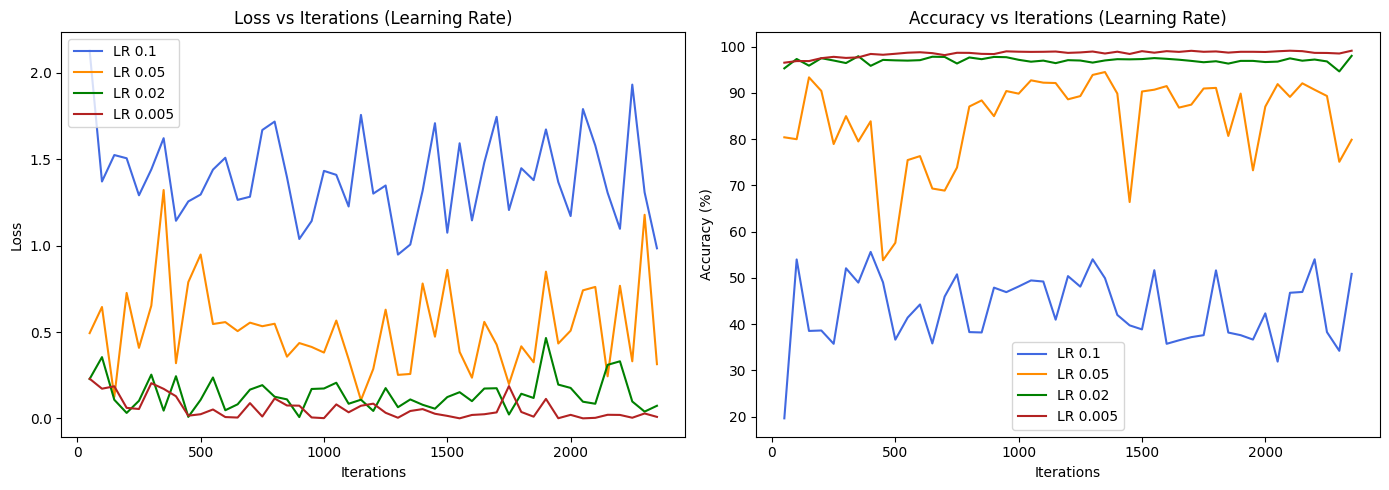

In [22]:
# 실험 2 모델 학습 결과 시각화
colors = ['royalblue', 'darkorange', 'green', 'firebrick']

plt.figure(figsize=(14, 5))

# (1) Loss vs Iterations
plt.subplot(1, 2, 1)
for (lr, (iters, losses, _)), color in zip(logs.items(), colors):
    plt.plot(iters, losses, label=f'LR {lr}', color=color)
plt.title('Loss vs Iterations (Learning Rate)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()

# (2) Accuracy vs Iterations
plt.subplot(1, 2, 2)
for (lr, (iters, _, accs)), color in zip(logs.items(), colors):
    plt.plot(iters, accs, label=f'LR {lr}', color=color)
plt.title('Accuracy vs Iterations (Learning Rate)')
plt.xlabel('Iterations')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- lr 0.1은 loss가 높고 불안정하며 오르락 내리락하는 모습을 보임
  - 너무 빨라서 overshooting 발산 가능성이 있음
- lr 0.05는 0.1보다는 낮은 loss를 보이지만, 여전히 진동이 심함
- lr 0.02는 이전보다 훨씬 낮아진 loss를 보임 -> 빠르게 수렴하고 안정적인 모습을 보임
- lr 0.005는 천천히 떨어지지만 학습이 오래 걸리지만, 가장 안정적인 모습을 보여줌
---
- lr 0.1과 0.05는 accuracy가 낮고 진동을 보임 -> 학습이 불안정함
- lr 0.02는 빠르게 높은 accuracy에 도달하고, 그 accuracy를 유지하는 모습을 보임
- lr 0.005는 느리지만 꾸준하고 안정적인 정확도 상승을 보임
---
- hidden_dim과 마찬가지로 적절한 learning_rate를 찾는 것이 중요함
  - learning_rate가 너무 크면 -> overshooting 가능성이 있음
  - learning_rate가 너무 작으면 -> 안정적인 모습을 보이지만, 결과가 나오기 까지 학습이 너무 오래 걸릴 수 있음
  - 따라서 learning_rate가 무조건 작다고 좋은 것이 아니라 득실이 있기 때문에 최적을 찾아야함

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # 출력크기 = (28+(2*0)-5)/1 + 1 = 24
        # 16개의 24 X 24 feature map 생성

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0) # cnn1 의 out_channels
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 10)  # 입력 차원 및 출력 차원 지정

        # 공식 적용 과정
        # cnn1 : (28 +(2*0)-5)/1 + 1 = 24 -> (16, 24, 24)
        # maxPool1 : (24-2)/2 + 1 = 12 -> (16, 12, 12)
        # cnn2 : (12 +(2*0)-5)/1 + 1 = 8 -> (32, 8, 8)
        # maxPool2 : (8-2)/2 + 1 = 4 -> (32, 4, 4)

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0),-1)
        # Fully Connected Layer는 1차원 백터만 받기 때문에 (ex) (64,32,4,4)이면 -> (64,512)로 바꾸어줘야함
        # 즉, (batch_size, 나머지 차원을 모두 곱해서 1D로 자동 변환)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [24]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [27]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs,labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.argmax(outputs,dim=1)

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.1678077680773796
Epoch 2, Loss: 0.04042389298184524
Epoch 3, Loss: 0.026920779697506617
Epoch 4, Loss: 0.02043110902259799
Epoch 5, Loss: 0.016224476434768282
Epoch 6, Loss: 0.011742436744010288
Epoch 7, Loss: 0.010901818841778176
Epoch 8, Loss: 0.008237780162417874
Epoch 9, Loss: 0.0066993064152818475
Epoch 10, Loss: 0.006770103621522333
Epoch 11, Loss: 0.005787027915216061
Epoch 12, Loss: 0.004866860448108351
Epoch 13, Loss: 0.004467219020262145
Epoch 14, Loss: 0.004101399028956103
Epoch 15, Loss: 0.0026107797970639684
Epoch 16, Loss: 0.0026489004871397158
Epoch 17, Loss: 0.002401408219103054
Epoch 18, Loss: 0.0014129520269722977
Epoch 19, Loss: 0.003211265647427845
Epoch 20, Loss: 0.0012887850214350087


#### **CNN 학습 결과**

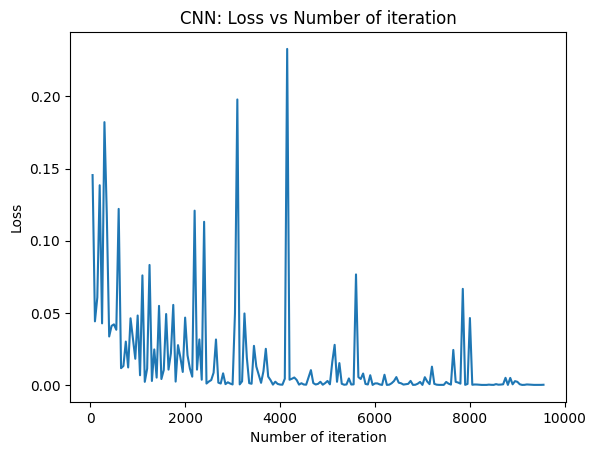

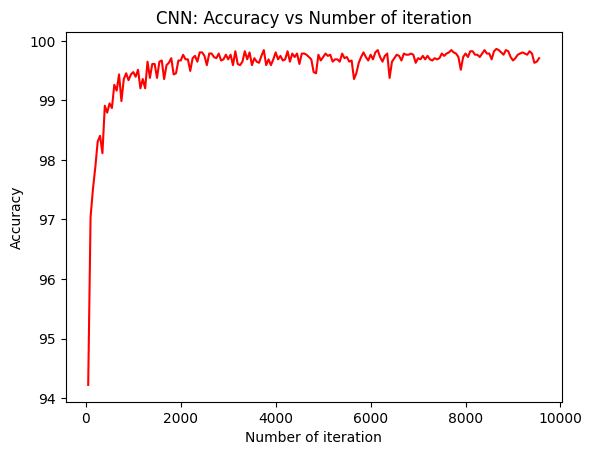

In [28]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
- ANN 모델의 하이퍼파라미터를 여러 가지로 튜닝해 보고, 바로 다음으로 CNN 모델 학습 실험을 해보니 각 모델의 차이점이 더욱 드러났다.
- ANN은 상대적으로 학습 속도가 빨랐고, lr과 hidden dim을 최적화한 상태에서 빠른 수렴 속도와 낮은 loss, 높은 accurary를 보였지만, 그래도 CNN와 비교하면 초기 loss값이 상대적으로 높음을 알 수 있다.
- CNN은 총 20번의 epoch 중 첫번째 epoch에서 바로 0.17의 loss를 보였으며 그 다음 부터 0.0에 계속해서 수렴하며 더욱 정밀하게 loss를 줄여나갔다.
- CNN은 복잡도가 상대적으로 높아 학습 속도가 약간 느리지만, 공간 정보 손실이 없고, 필터를 통해 지역적 특징을 추출하여 이미지 인식에 강력한 모습을 보였다.
